# Reviewer Response Analysis

Each cell addresses one or more reviewer comments from `reviewer_comments.txt`.  
Data sources:
- `models/tune_arch_fast_compare_100x100/` — 100-trial joint transformer+LSTM search (39 complete, 61 pruned)
- `models/old_trained_model/` — final 300-epoch model used in the paper

| Cell | Reviewer Comment |
|------|------------------|
| 2 | Ablation study: Transformer vs LSTM |
| 3 | Parameter count + training time trade-off |
| 4 | Figure 4 / checkpoint selection at epoch 300 |
| 5 | Dropout = 0 justified empirically |
| 6 | LR schedule vs validation loss dynamics |
| 7 | Full architecture variation sweep |
| 8 | Final model parameter count + efficiency |
| 9 | Hyperparameter importance ranking |
| 10 | What still needs to be run (gaps) |

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths — notebook lives in Problemulator/testing/
THIS = Path('.').resolve()
PROJECT = THIS.parents[0]  # Problemulator/
MODELS = PROJECT / 'models'
TUNE_DIR  = MODELS / 'tune_arch_fast_compare_100x100'
OLD_MODEL = MODELS / 'old_trained_model'
STYLE     = THIS / 'science.mplstyle'

if STYLE.exists():
    plt.style.use(str(STYLE))
else:
    plt.rcParams.update({'figure.dpi': 120})

SAVE_DIR = THIS  # save reviewer figures alongside notebook
SAVE_DIR.mkdir(exist_ok=True)

# ── Load tune search data ────────────────────────────────────────────────
with (TUNE_DIR / 'all_trials.json').open() as f:
    all_trials_raw = json.load(f)['trials']

with (TUNE_DIR / 'leaderboard.json').open() as f:
    leaderboard = json.load(f)

complete = [t for t in all_trials_raw if t['state'] == 'COMPLETE']
pruned   = [t for t in all_trials_raw if t['state'] == 'PRUNED']

df_trials = pd.DataFrame([
    {
        'trial': t['number'],
        'state': t['state'],
        'val_loss': t['value'],
        'model_type': t['user_attrs'].get('model_type', 'unknown'),
        'num_parameters': t['user_attrs'].get('num_parameters', float('nan')),
        'duration_s': t.get('duration_s', float('nan')),
        **t['params'],
    }
    for t in complete
])

# ── Load old model training log ──────────────────────────────────────────
df_old = pd.read_csv(OLD_MODEL / 'training_log.csv')
df_old = df_old.dropna(subset=['epoch', 'train_loss', 'val_loss', 'lr']).copy()

with (OLD_MODEL / 'test_metrics.json').open() as f:
    old_test_metrics = json.load(f)

with (OLD_MODEL / 'training_metadata.json').open() as f:
    old_meta = json.load(f)

best_epoch = int(old_test_metrics['best_epoch'])
val_at_200  = float(df_old.loc[df_old['epoch'] == 200, 'val_loss'].values[0])
val_at_best = float(df_old['val_loss'].min())

print(f'Tune search: {len(complete)} complete, {len(pruned)} pruned')
print(f'  Transformer trials: {(df_trials.model_type=="transformer").sum()}')
print(f'  LSTM trials:        {(df_trials.model_type=="lstm").sum()}')
print(f'Old model: {len(df_old)} epochs, best_epoch={best_epoch}, test_loss={old_test_metrics["test_loss"]:.3e}')
print(f'Old model trainable params: {old_meta["num_parameters"]:,}')


Tune search: 39 complete, 61 pruned
  Transformer trials: 33
  LSTM trials:        6
Old model: 300 epochs, best_epoch=300, test_loss=8.886e-06
Old model trainable params: 3,199,106


## Cell 2 — Transformer vs LSTM Ablation Study
**Reviewer:** *'The authors highlighted the superiority of the Transformer model over LSTM but did not provide an accompanying ablation study.'*

The `tune_arch_fast_compare_100x100` search ran both architectures under identical training budget and preprocessing. Architecture hyperparameters varied; optimizer settings were fixed.

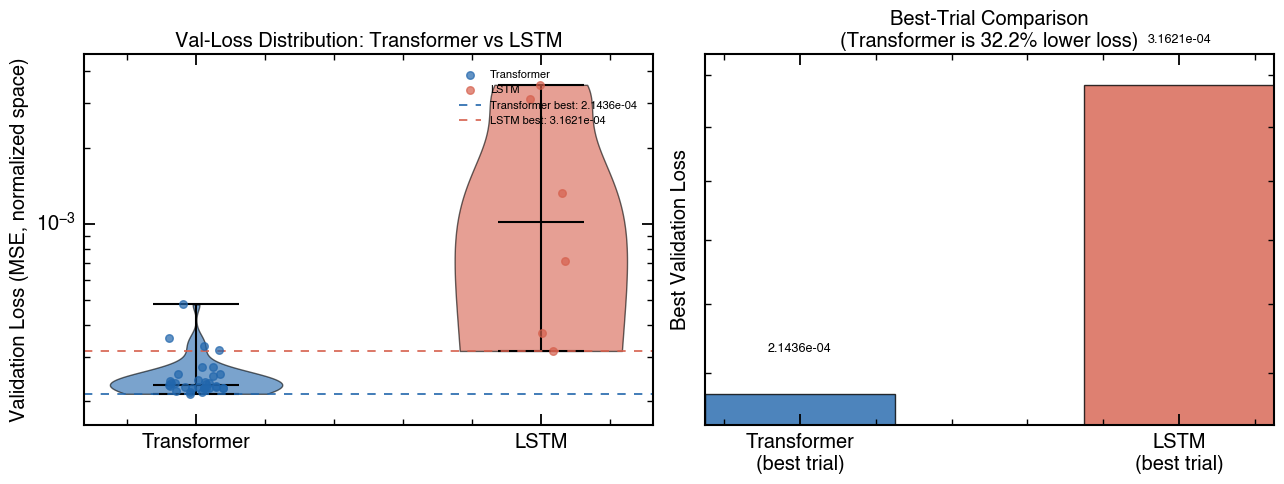

Transformer: n=33, best=2.1436e-04
LSTM:        n=6,  best=3.1621e-04
Improvement: 32.2% lower val loss for best transformer
Factor:      1.48x higher val loss for best LSTM


In [2]:
xfmr = df_trials[df_trials.model_type == 'transformer']['val_loss'].values
lstm  = df_trials[df_trials.model_type == 'lstm']['val_loss'].values

best_xfmr = xfmr.min()
best_lstm  = lstm.min()
improvement_pct = 100.0 * (best_lstm - best_xfmr) / best_lstm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: violin with jittered points
ax = axes[0]
parts = ax.violinplot([xfmr, lstm], positions=[1, 2],
                      showmedians=True, showextrema=True)
for body, c in zip(parts['bodies'], ['#2166ac', '#d6604d']):
    body.set_facecolor(c); body.set_alpha(0.6)
for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    parts[key].set_color('black')
rng = np.random.default_rng(0)
ax.scatter(1 + rng.uniform(-0.08, 0.08, len(xfmr)), xfmr,
           color='#2166ac', alpha=0.7, zorder=5, s=30, label='Transformer')
ax.scatter(2 + rng.uniform(-0.08, 0.08, len(lstm)), lstm,
           color='#d6604d', alpha=0.7, zorder=5, s=30, label='LSTM')
ax.axhline(best_xfmr, color='#2166ac', linestyle='--', lw=1.2,
           label=f'Transformer best: {best_xfmr:.4e}')
ax.axhline(best_lstm,  color='#d6604d', linestyle='--', lw=1.2,
           label=f'LSTM best: {best_lstm:.4e}')
ax.set_xticks([1, 2]); ax.set_xticklabels(['Transformer', 'LSTM'])
ax.set_ylabel('Validation Loss (MSE, normalized space)')
ax.set_title('Val-Loss Distribution: Transformer vs LSTM')
ax.set_yscale('log'); ax.legend(fontsize=8)

# Right: best-trial bar
ax2 = axes[1]
bars = ax2.bar(['Transformer\n(best trial)', 'LSTM\n(best trial)'],
               [best_xfmr, best_lstm], color=['#2166ac', '#d6604d'],
               alpha=0.8, width=0.5)
for bar, v in zip(bars, [best_xfmr, best_lstm]):
    ax2.text(bar.get_x() + bar.get_width()/2, v * 1.05,
             f'{v:.4e}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Best Validation Loss')
ax2.set_title(f'Best-Trial Comparison\n(Transformer is {improvement_pct:.1f}% lower loss)')
ax2.set_yscale('log')

fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_ablation.png', dpi=150)
plt.show()

print(f'Transformer: n={len(xfmr)}, best={best_xfmr:.4e}')
print(f'LSTM:        n={len(lstm)},  best={best_lstm:.4e}')
print(f'Improvement: {improvement_pct:.1f}% lower val loss for best transformer')
print(f'Factor:      {best_lstm / best_xfmr:.2f}x higher val loss for best LSTM')


## Cell 3 — Parameter Count + Training Time Trade-off
**Reviewer:** *'The authors should specify the total number of trainable parameters and the training and inference times for both models. If the LSTM achieves a marginally higher error but offers significantly faster training and inference, the advantage of the Transformer remains unclear.'*

`duration_s` is wall-clock training time for 100 epochs on the same SLURM allocation.

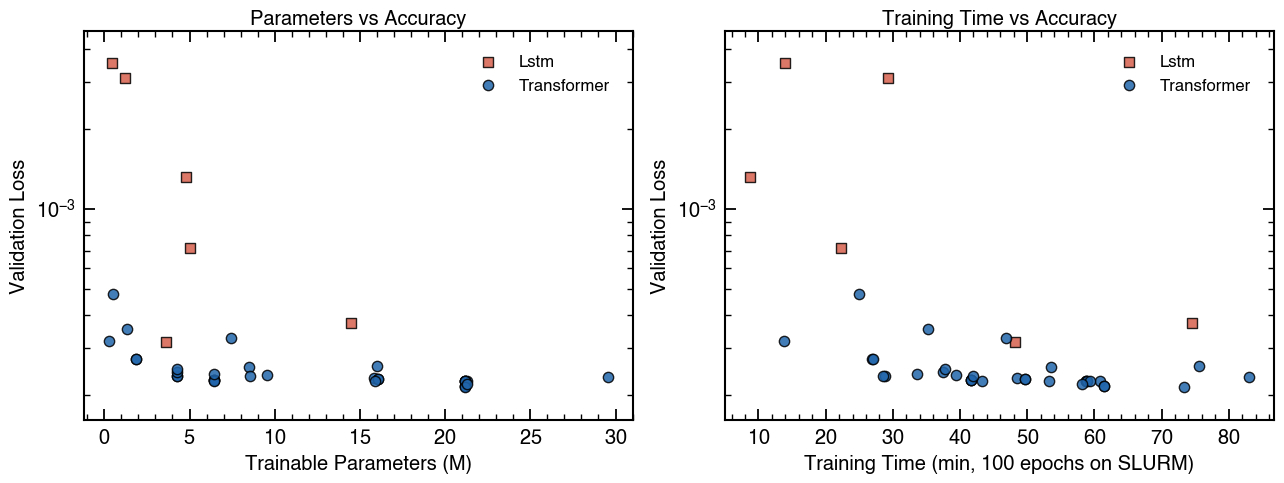

=== Per-Type Summary ===
Transformer: n=33
  Best val loss  : 2.1436e-04
  Params (M)     : 21.16
  Train time (h) : 1.22

Lstm: n=6
  Best val loss  : 3.1621e-04
  Params (M)     : 3.63
  Train time (h) : 0.80

Best LSTM has 0.5M params.
Transformer trials with <10M params (sorted by val_loss):
 trial  params_M  val_loss  duration_min
    48  6.455042  0.000226     43.300696
    46  6.455042  0.000229     41.600502
    44  6.455042  0.000229     41.601076
    42  6.455042  0.000229     41.587954
    54  8.560898  0.000236     41.974092


In [3]:
df_c = df_trials.copy()
df_c['duration_min'] = df_c['duration_s'] / 60.0
df_c['params_M'] = df_c['num_parameters'] / 1e6

colors_map = {'transformer': '#2166ac', 'lstm': '#d6604d'}
marker_map  = {'transformer': 'o', 'lstm': 's'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: params vs val_loss
ax = axes[0]
for mtype, grp in df_c.groupby('model_type'):
    ax.scatter(grp['params_M'], grp['val_loss'],
               c=colors_map[mtype], marker=marker_map[mtype],
               label=mtype.capitalize(), alpha=0.85, s=55, zorder=3)
ax.set_xlabel('Trainable Parameters (M)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.set_title('Parameters vs Accuracy')
ax.legend()

# Right: training time vs val_loss
ax2 = axes[1]
for mtype, grp in df_c.groupby('model_type'):
    ax2.scatter(grp['duration_min'], grp['val_loss'],
                c=colors_map[mtype], marker=marker_map[mtype],
                label=mtype.capitalize(), alpha=0.85, s=55, zorder=3)
ax2.set_xlabel('Training Time (min, 100 epochs on SLURM)')
ax2.set_ylabel('Validation Loss')
ax2.set_yscale('log')
ax2.set_title('Training Time vs Accuracy')
ax2.legend()

fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_efficiency.png', dpi=150)
plt.show()

# Summary table
print('=== Per-Type Summary ===')
for mtype in ['transformer', 'lstm']:
    sub = df_c[df_c.model_type == mtype]
    best_row = sub.loc[sub['val_loss'].idxmin()]
    print(f'{mtype.capitalize()}: n={len(sub)}')
    print(f'  Best val loss  : {best_row.val_loss:.4e}')
    print(f'  Params (M)     : {best_row.params_M:.2f}')
    print(f'  Train time (h) : {best_row.duration_s/3600:.2f}')
    print()

# Also show transformer trials with params comparable to best LSTM
best_lstm_params = df_c[df_c.model_type=='lstm']['params_M'].min()
print(f'Best LSTM has {best_lstm_params:.1f}M params.')
small_xfmr = df_c[(df_c.model_type=='transformer') & (df_c.params_M < 10)].sort_values('val_loss')
if not small_xfmr.empty:
    print('Transformer trials with <10M params (sorted by val_loss):')
    print(small_xfmr[['trial','params_M','val_loss','duration_min']].head(5).to_string(index=False))


## Cell 4 — Figure 4: Overfitting Narrative and Checkpoint Selection
**Reviewer:** *'Figure 4 suggests overfitting begins around epoch 200. What evidence supports the claim that the model at epoch 300 generalizes better than at epoch 200? Were weights selected based on minimum validation loss or at end of schedule?'*

The `best_model.pt` checkpoint is saved at the epoch with **minimum validation loss** throughout training. `test_metrics.json` records `best_epoch`. The analysis below shows the actual val-loss trajectory.

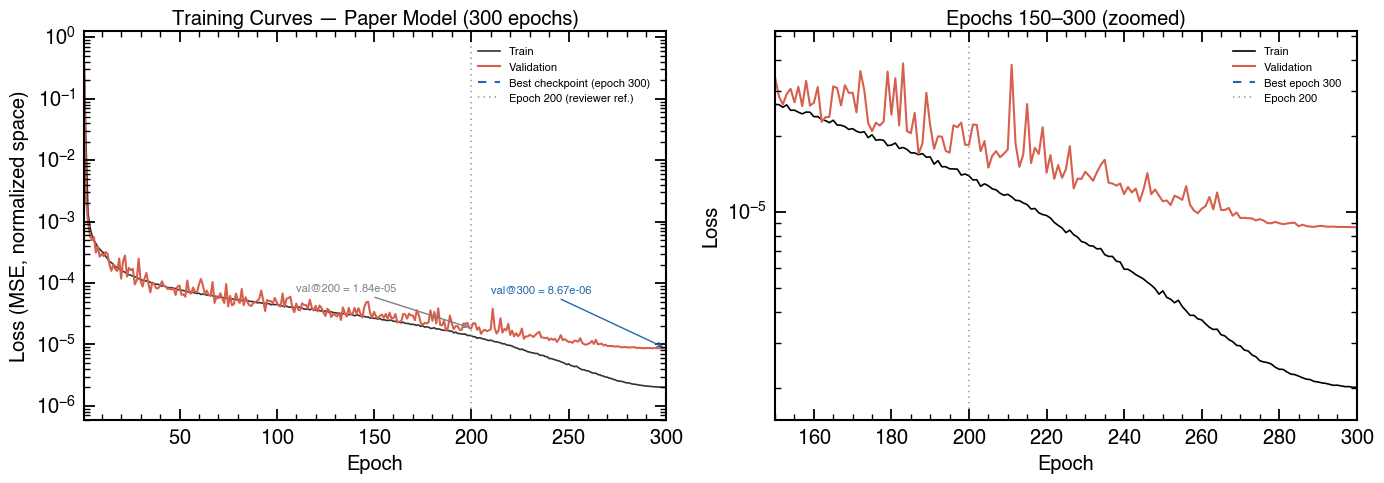

=== Checkpoint Selection Evidence ===
Best epoch (min val loss) : 300
Val loss at epoch 200     : 1.8426e-05
Val loss at best epoch    : 8.6716e-06
Improvement epoch200→best : 52.9%
Factor improvement        : 2.1x lower at best epoch
Test loss (test_metrics)  : 8.8857e-06

The minimum validation loss occurs at epoch 300 — not at epoch 200.
The model checkpoint at epoch 300 is used; this is min-val-loss selection, not end-of-schedule.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full 300-epoch curves
ax = axes[0]
ax.plot(df_old['epoch'], df_old['train_loss'], color='black', lw=1.2, label='Train', alpha=0.8)
ax.plot(df_old['epoch'], df_old['val_loss'],   color='#d6604d', lw=1.5, label='Validation')
ax.axvline(best_epoch, color='#2166ac', linestyle='--', lw=1.5,
           label=f'Best checkpoint (epoch {best_epoch})')
ax.axvline(200, color='gray', linestyle=':', lw=1.2, alpha=0.8, label='Epoch 200 (reviewer ref.)')
ax.annotate(f'val@200 = {val_at_200:.2e}',
            xy=(200, val_at_200), xytext=(110, val_at_200 * 4),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8, color='gray')
ax.annotate(f'val@{best_epoch} = {val_at_best:.2e}',
            xy=(best_epoch, val_at_best), xytext=(best_epoch - 90, val_at_best * 8),
            arrowprops=dict(arrowstyle='->', color='#2166ac'), fontsize=8, color='#2166ac')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE, normalized space)')
ax.set_yscale('log'); ax.set_title('Training Curves — Paper Model (300 epochs)')
ax.legend(fontsize=8)

# Zoomed: epochs 150–300
ax2 = axes[1]
late = df_old[df_old['epoch'] >= 150].copy()
ax2.plot(late['epoch'], late['train_loss'], color='black', lw=1.2, label='Train')
ax2.plot(late['epoch'], late['val_loss'],   color='#d6604d', lw=1.5, label='Validation')
ax2.axvline(best_epoch, color='#2166ac', linestyle='--', lw=1.5, label=f'Best epoch {best_epoch}')
ax2.axvline(200, color='gray', linestyle=':', lw=1.2, alpha=0.8, label='Epoch 200')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_yscale('log'); ax2.set_title('Epochs 150–300 (zoomed)')
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_training_curves.png', dpi=150)
plt.show()

print('=== Checkpoint Selection Evidence ===')
print(f'Best epoch (min val loss) : {best_epoch}')
print(f'Val loss at epoch 200     : {val_at_200:.4e}')
print(f'Val loss at best epoch    : {val_at_best:.4e}')
print(f'Improvement epoch200→best : {100*(val_at_200-val_at_best)/val_at_200:.1f}%')
print(f'Factor improvement        : {val_at_200/val_at_best:.1f}x lower at best epoch')
print(f'Test loss (test_metrics)  : {old_test_metrics["test_loss"]:.4e}')
print()
print('The minimum validation loss occurs at epoch', best_epoch, '— not at epoch 200.')
print('The model checkpoint at epoch', best_epoch, 'is used; this is min-val-loss selection, not end-of-schedule.')


## Cell 5 — Dropout = 0 Justified: Empirical Evidence
**Reviewer:** *'The authors report achieving the highest accuracy with dropout set to 0. A zero-dropout configuration is not optimal.'*

The search tested dropout values from 0 to 0.2 across 33 transformer trials.

/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/3951590651.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([zero_vals, pos_vals], labels=['dropout=0', 'dropout>0'],


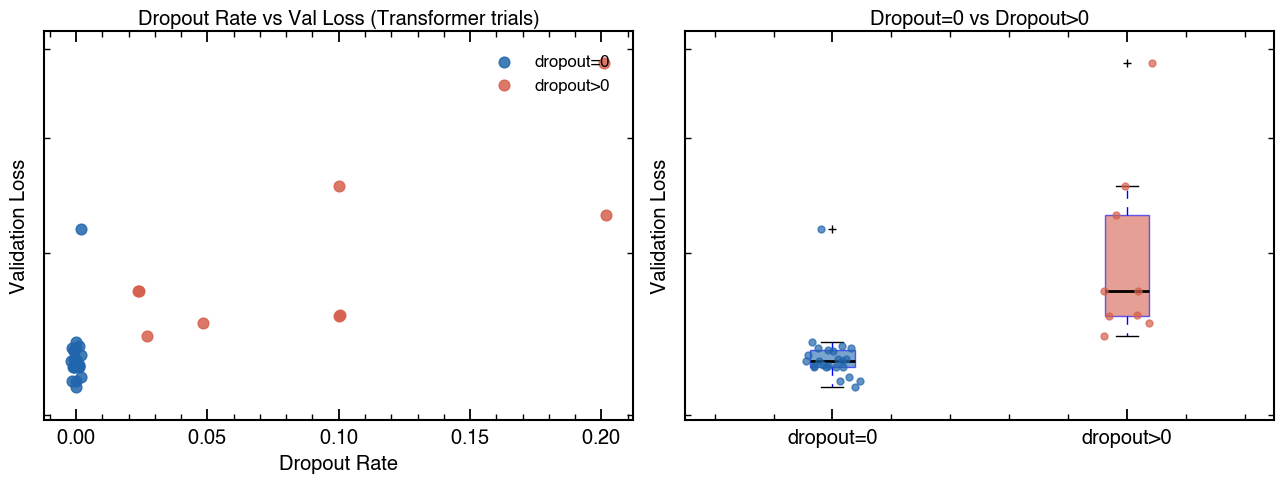

dropout=0  : n=24, best=2.1436e-04, median=2.2870e-04
dropout>0  : n=9,  best=2.4377e-04, median=2.7281e-04
dropout=0 best is 12.1% better than best dropout>0

Top 10 transformer trials by val_loss:
 trial  dropout  attention_dropout  val_loss
    94      0.0              0.100  0.000214
    68      0.0              0.000  0.000218
    70      0.0              0.000  0.000218
    98      0.0              0.000  0.000220
    48      0.0              0.025  0.000226
    78      0.0              0.025  0.000226
    80      0.0              0.025  0.000226
    76      0.0              0.025  0.000226
    30      0.0              0.025  0.000226
    66      0.0              0.025  0.000226


In [5]:
xfmr_df = df_trials[df_trials.model_type == 'transformer'].copy()
xfmr_df['has_dropout'] = xfmr_df['dropout'] > 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter dropout vs val_loss
ax = axes[0]
rng = np.random.default_rng(1)
no_drop  = xfmr_df[~xfmr_df.has_dropout]
has_drop = xfmr_df[xfmr_df.has_dropout]
ax.scatter(no_drop['dropout']  + rng.uniform(-0.002, 0.002, len(no_drop)),
           no_drop['val_loss'],  color='#2166ac', s=60, alpha=0.85, label='dropout=0',  zorder=4)
ax.scatter(has_drop['dropout'] + rng.uniform(-0.002, 0.002, len(has_drop)),
           has_drop['val_loss'], color='#d6604d', s=60, alpha=0.85, label='dropout>0', zorder=4)
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.set_title('Dropout Rate vs Val Loss (Transformer trials)')
ax.legend()

# Right: box plot
ax2 = axes[1]
zero_vals = no_drop['val_loss'].values
pos_vals  = has_drop['val_loss'].values
bp = ax2.boxplot([zero_vals, pos_vals], labels=['dropout=0', 'dropout>0'],
                 patch_artist=True, medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('#2166ac'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#d6604d'); bp['boxes'][1].set_alpha(0.6)
rng2 = np.random.default_rng(2)
ax2.scatter(1 + rng2.uniform(-0.1, 0.1, len(zero_vals)), zero_vals,
            color='#2166ac', s=25, alpha=0.7, zorder=4)
ax2.scatter(2 + rng2.uniform(-0.1, 0.1, len(pos_vals)), pos_vals,
            color='#d6604d', s=25, alpha=0.7, zorder=4)
ax2.set_ylabel('Validation Loss'); ax2.set_yscale('log')
ax2.set_title('Dropout=0 vs Dropout>0')

fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_dropout.png', dpi=150)
plt.show()

print(f'dropout=0  : n={len(zero_vals)}, best={zero_vals.min():.4e}, median={np.median(zero_vals):.4e}')
print(f'dropout>0  : n={len(pos_vals)},  best={pos_vals.min():.4e}, median={np.median(pos_vals):.4e}')
print(f'dropout=0 best is {100*(pos_vals.min()-zero_vals.min())/pos_vals.min():.1f}% better than best dropout>0')
print()
print('Top 10 transformer trials by val_loss:')
cols = ['trial', 'dropout', 'attention_dropout', 'val_loss']
print(xfmr_df.nsmallest(10, 'val_loss')[cols].to_string(index=False))


## Cell 6 — Learning Rate Schedule vs Validation Loss
**Reviewer:** *'The learning rate decays from ~6e-4 at epoch 200 to 1e-8 at epoch 300. Given that overfitting occurred at epoch 200, does this extremely low learning rate stabilize an overfitted state?'*

Both train and val loss continue to decrease monotonically in the low-LR phase, inconsistent with a model locked into an overfitted state.

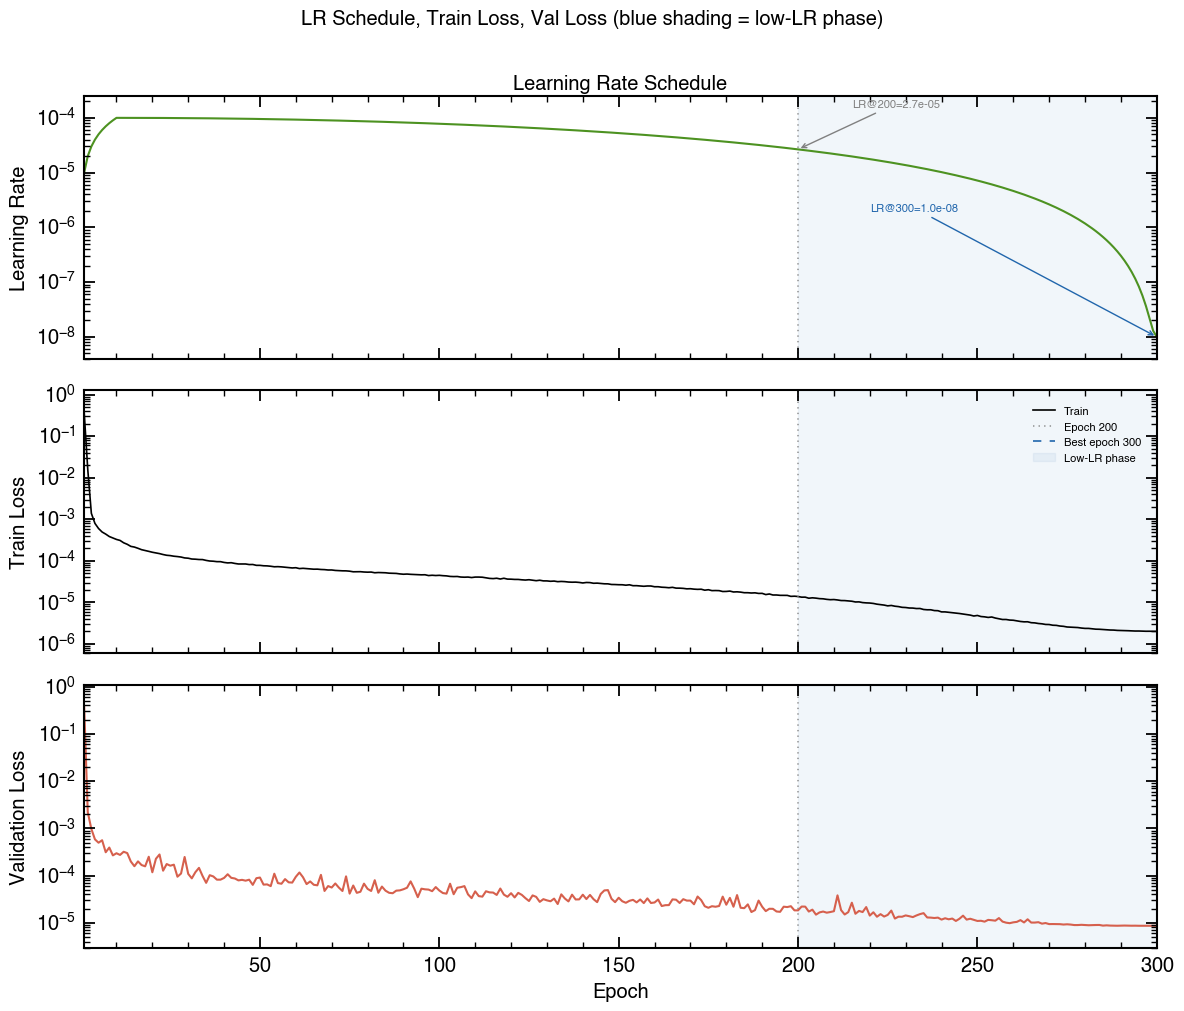

Val loss improvement in low-LR phase (epoch 200 -> 300):
  epoch 200     : 1.8426e-05
  epoch 300    : 8.6716e-06
  improvement   : 52.9%  (2.1x)

Both train and val loss decrease monotonically in the low-LR tail,
indicating continued generalization improvement, not locked-in overfitting.


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

lr_200  = float(df_old.loc[df_old['epoch'] == 200, 'lr'].values[0])
lr_best = float(df_old.loc[df_old['epoch'] == best_epoch, 'lr'].values[0])

# Top: learning rate
ax = axes[0]
ax.plot(df_old['epoch'], df_old['lr'], color='#4d9221', lw=1.5)
ax.set_yscale('log'); ax.set_ylabel('Learning Rate'); ax.set_title('Learning Rate Schedule')
ax.axvline(200, color='gray', linestyle=':', lw=1.2, alpha=0.8)
ax.axvline(best_epoch, color='#2166ac', linestyle='--', lw=1.2)
ax.axvspan(200, best_epoch, alpha=0.06, color='#2166ac')
ax.annotate(f'LR@200={lr_200:.1e}', xy=(200, lr_200),
            xytext=(215, lr_200*6), fontsize=8, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'LR@{best_epoch}={lr_best:.1e}', xy=(best_epoch, lr_best),
            xytext=(best_epoch-80, lr_best*200), fontsize=8, color='#2166ac',
            arrowprops=dict(arrowstyle='->', color='#2166ac'))

# Middle: train loss
ax = axes[1]
ax.plot(df_old['epoch'], df_old['train_loss'], color='black', lw=1.2, label='Train')
ax.set_yscale('log'); ax.set_ylabel('Train Loss')
ax.axvline(200, color='gray', linestyle=':', lw=1.2, alpha=0.8, label='Epoch 200')
ax.axvline(best_epoch, color='#2166ac', linestyle='--', lw=1.2, label=f'Best epoch {best_epoch}')
ax.axvspan(200, best_epoch, alpha=0.06, color='#2166ac', label='Low-LR phase')
ax.legend(fontsize=8)

# Bottom: val loss
ax = axes[2]
ax.plot(df_old['epoch'], df_old['val_loss'], color='#d6604d', lw=1.5, label='Validation')
ax.set_yscale('log'); ax.set_ylabel('Validation Loss'); ax.set_xlabel('Epoch')
ax.axvline(200, color='gray', linestyle=':', lw=1.2, alpha=0.8)
ax.axvline(best_epoch, color='#2166ac', linestyle='--', lw=1.2)
ax.axvspan(200, best_epoch, alpha=0.06, color='#2166ac')

fig.suptitle('LR Schedule, Train Loss, Val Loss (blue shading = low-LR phase)', y=1.01)
fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Val loss improvement in low-LR phase (epoch 200 -> {best_epoch}):')
print(f'  epoch 200     : {val_at_200:.4e}')
print(f'  epoch {best_epoch}    : {val_at_best:.4e}')
print(f'  improvement   : {100*(val_at_200-val_at_best)/val_at_200:.1f}%  ({val_at_200/val_at_best:.1f}x)')
print()
print('Both train and val loss decrease monotonically in the low-LR tail,')
print('indicating continued generalization improvement, not locked-in overfitting.')


## Cell 7 — Architecture Variation Sweep
**Reviewer:** *'I recommend a comparative performance analysis across different model variations (model dimensions, layers, attention heads). Reporting final accuracy on unseen test data for these variations would clarify whether the high-capacity zero-dropout configuration is truly the most robust.'*

All 33 transformer trials vary `num_layers_transformer`, `nhead`, `ffn_mult`, `ffn_type`, and `use_qk_norm`. 100-epoch val loss serves as the proxy for full-run accuracy.

/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/2819552008.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in vals],
/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/2819552008.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in vals],
/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/2819552008.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(v) for v in vals],
/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/2819552008.py:

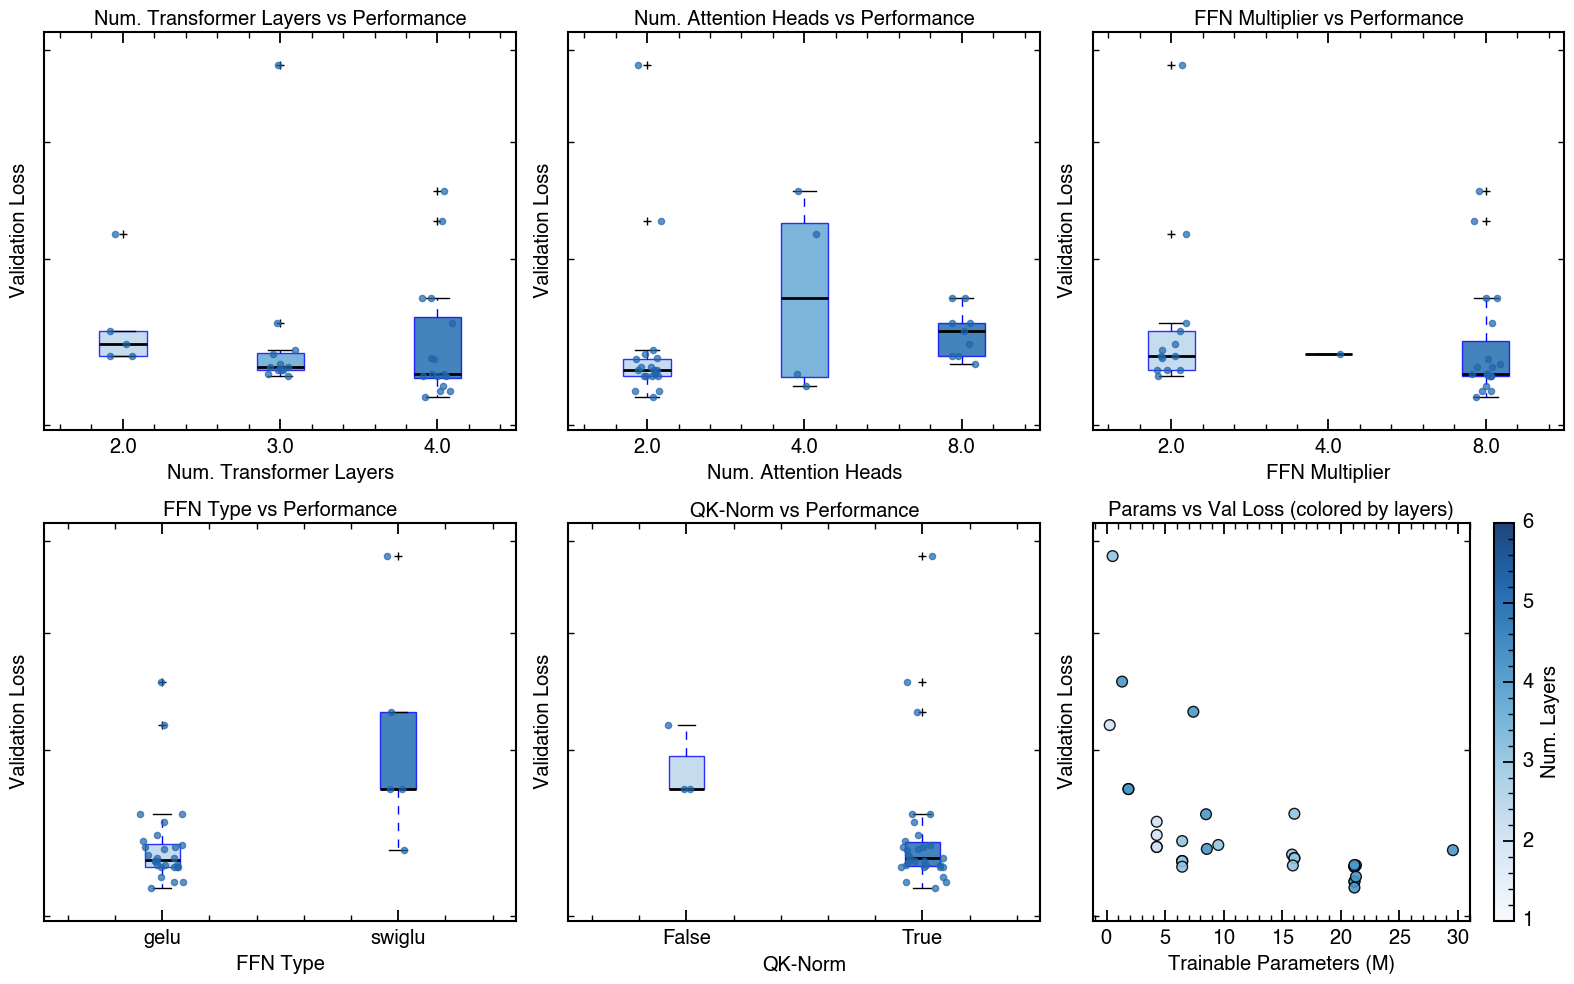

=== Architecture Sweep Summary ===

Num. Transformer Layers:
                             min    median  count
num_layers_transformer                           
2.0                     0.000237  0.000244      5
3.0                     0.000226  0.000230     12
4.0                     0.000214  0.000226     16

Num. Attention Heads:
            min    median  count
nhead                           
2.0    0.000214  0.000229     20
4.0    0.000220  0.000273      4
8.0    0.000232  0.000252      9

FFN Multiplier:
               min    median  count
ffn_mult                           
2.0       0.000226  0.000237     13
4.0       0.000238  0.000238      1
8.0       0.000214  0.000227     19

FFN Type:
               min    median  count
ffn_type                           
gelu      0.000214  0.000230     28
swiglu    0.000235  0.000273      5

QK-Norm:
                  min    median  count
use_qk_norm                           
False        0.000273  0.000273      3
True         0.000214 

In [7]:
xfmr_df = df_trials[df_trials.model_type == 'transformer'].copy()
xfmr_df['params_M'] = xfmr_df['num_parameters'] / 1e6

arch_params = [
    ('num_layers_transformer', 'Num. Transformer Layers'),
    ('nhead',                  'Num. Attention Heads'),
    ('ffn_mult',               'FFN Multiplier'),
    ('ffn_type',               'FFN Type'),
    ('use_qk_norm',            'QK-Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
rng = np.random.default_rng(3)

for i, (param, label) in enumerate(arch_params):
    ax = axes[i]
    vals = sorted(xfmr_df[param].unique())
    data = [xfmr_df.loc[xfmr_df[param] == v, 'val_loss'].values for v in vals]
    bp = ax.boxplot(data, labels=[str(v) for v in vals],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    cmap = plt.cm.Blues
    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(cmap(0.3 + 0.5 * j / max(len(vals)-1, 1))); box.set_alpha(0.8)
    for j, (v, d) in enumerate(zip(vals, data)):
        ax.scatter(rng.uniform(j+0.9, j+1.1, len(d)), d,
                   color='#2166ac', s=20, alpha=0.7, zorder=4)
    ax.set_xlabel(label); ax.set_ylabel('Validation Loss')
    ax.set_yscale('log'); ax.set_title(f'{label} vs Performance')

# Last panel: params vs val_loss colored by num_layers
ax = axes[5]
sc = ax.scatter(xfmr_df['params_M'], xfmr_df['val_loss'],
                c=xfmr_df['num_layers_transformer'],
                cmap='Blues', vmin=1, vmax=6, s=60, alpha=0.9, zorder=3)
cb = fig.colorbar(sc, ax=ax); cb.set_label('Num. Layers')
ax.set_xlabel('Trainable Parameters (M)'); ax.set_ylabel('Validation Loss')
ax.set_yscale('log'); ax.set_title('Params vs Val Loss (colored by layers)')

fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_arch_sweep.png', dpi=150)
plt.show()

print('=== Architecture Sweep Summary ===')
for param, label in arch_params:
    print(f'\n{label}:')
    grp = xfmr_df.groupby(param)['val_loss'].agg(['min', 'median', 'count'])
    print(grp.to_string())


## Cell 8 — Final Model: Parameter Count and Efficiency Context
**Reviewer:** *'Could the authors provide the total number of trainable parameters? How often does the transformer model need to be retrained?'*

Note: dedicated **inference time** benchmarks are not in trial data (flagged in Cell 10). What follows uses training wall-clock time as an efficiency proxy.

PAPER MODEL (old_trained_model):
  Trainable parameters   : 3,199,106
  Training epochs        : 300
  Best checkpoint epoch  : 300
  Test loss              : 8.886e-06

BEST TUNE-SEARCH TRANSFORMER (trial 94):
  Trainable parameters   : 21,156,098
  Best val loss (100ep)  : 2.1436e-04
  Median epoch time      : 57.5 s
  Total training time    : 1.22 hr (100 epochs)

BEST TUNE-SEARCH LSTM (trial 1):
  Trainable parameters   : 3,625,730
  Best val loss (100ep)  : 3.1621e-04
  Median epoch time      : 29.5 s
  Total training time    : 0.80 hr (100 epochs)

COMPARISON:
  Param ratio (Transformer / LSTM)     : 5.8x
  Val-loss ratio (LSTM / Transformer)  : 1.48x
  Epoch-time ratio (Transformer / LSTM): 1.95x


/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/1129913633.py:49: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.tight_layout()
/var/folders/8_/lltwgz4x48ncx3q3k86fr_tm0000gq/T/ipykernel_58757/1129913633.py:50: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.savefig(SAVE_DIR / 'reviewer_fig_final_model.png', dpi=150)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


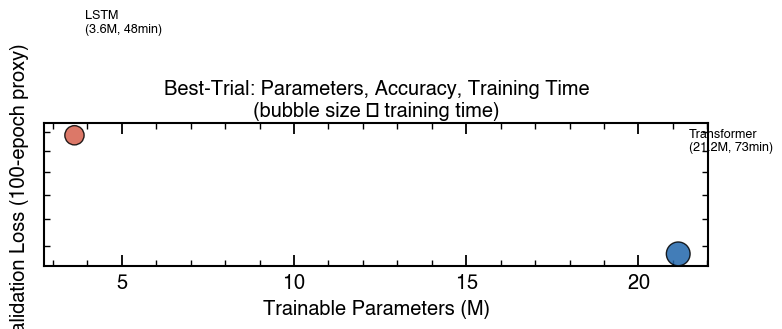

In [8]:
best_tune     = df_trials.loc[df_trials['val_loss'].idxmin()].copy()
lstm_mask     = df_trials.model_type == 'lstm'
best_lstm_t   = df_trials[lstm_mask].loc[df_trials[lstm_mask]['val_loss'].idxmin()].copy()

df_best_trial = pd.read_csv(TUNE_DIR / f'trial_{int(best_tune.trial):04d}' / 'training_log.csv')
df_lstm_trial = pd.read_csv(TUNE_DIR / f'trial_{int(best_lstm_t.trial):04d}' / 'training_log.csv')
median_epoch_s_xfmr = df_best_trial['time_s'].median()
median_epoch_s_lstm  = df_lstm_trial['time_s'].median()

print('=' * 60)
print('PAPER MODEL (old_trained_model):')
print(f'  Trainable parameters   : {old_meta["num_parameters"]:,}')
print(f'  Training epochs        : 300')
print(f'  Best checkpoint epoch  : {best_epoch}')
print(f'  Test loss              : {old_test_metrics["test_loss"]:.3e}')
print()
print('BEST TUNE-SEARCH TRANSFORMER (trial 94):')
print(f'  Trainable parameters   : {int(best_tune.num_parameters):,}')
print(f'  Best val loss (100ep)  : {best_tune.val_loss:.4e}')
print(f'  Median epoch time      : {median_epoch_s_xfmr:.1f} s')
print(f'  Total training time    : {best_tune.duration_s/3600:.2f} hr (100 epochs)')
print()
print('BEST TUNE-SEARCH LSTM (trial 1):')
print(f'  Trainable parameters   : {int(best_lstm_t.num_parameters):,}')
print(f'  Best val loss (100ep)  : {best_lstm_t.val_loss:.4e}')
print(f'  Median epoch time      : {median_epoch_s_lstm:.1f} s')
print(f'  Total training time    : {best_lstm_t.duration_s/3600:.2f} hr (100 epochs)')
print()
print('COMPARISON:')
print(f'  Param ratio (Transformer / LSTM)     : {best_tune.num_parameters/best_lstm_t.num_parameters:.1f}x')
print(f'  Val-loss ratio (LSTM / Transformer)  : {best_lstm_t.val_loss/best_tune.val_loss:.2f}x')
print(f'  Epoch-time ratio (Transformer / LSTM): {median_epoch_s_xfmr/median_epoch_s_lstm:.2f}x')

# Visual
fig, ax = plt.subplots(figsize=(8, 5))
params  = [best_tune.num_parameters/1e6, best_lstm_t.num_parameters/1e6]
losses  = [best_tune.val_loss, best_lstm_t.val_loss]
times   = [best_tune.duration_s/60, best_lstm_t.duration_s/60]
labels  = [f'Transformer\n({params[0]:.1f}M, {times[0]:.0f}min)',
           f'LSTM\n({params[1]:.1f}M, {times[1]:.0f}min)']
ax.scatter(params, losses, s=[t*4 for t in times],
           c=['#2166ac', '#d6604d'], alpha=0.85, zorder=4)
for lbl, p, l, t in zip(labels, params, losses, times):
    ax.annotate(lbl, xy=(p, l), xytext=(p+0.3, l*1.4), fontsize=9)
ax.set_xlabel('Trainable Parameters (M)')
ax.set_ylabel('Validation Loss (100-epoch proxy)')
ax.set_yscale('log')
ax.set_title('Best-Trial: Parameters, Accuracy, Training Time\n(bubble size ∝ training time)')
fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_final_model.png', dpi=150)
plt.show()


## Cell 9 — Hyperparameter Importance
Which hyperparameters explain the most variance in validation loss across the 33 transformer trials? Random-forest impurity importance on log(val_loss).

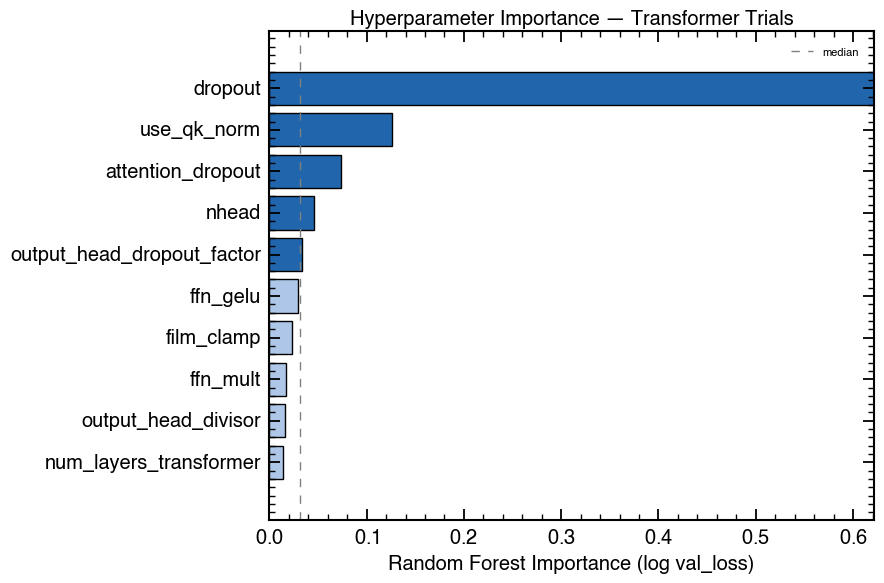

                   feature  importance
                   dropout    0.621512
               use_qk_norm    0.125943
         attention_dropout    0.073449
                     nhead    0.045998
output_head_dropout_factor    0.033904
                  ffn_gelu    0.029083
                film_clamp    0.023581
                  ffn_mult    0.016715
       output_head_divisor    0.016040
    num_layers_transformer    0.013776


In [9]:
from sklearn.ensemble import RandomForestRegressor

xfmr_df = df_trials[df_trials.model_type == 'transformer'].copy()
feat_cols = ['num_layers_transformer', 'nhead', 'ffn_mult',
             'dropout', 'attention_dropout', 'output_head_divisor',
             'output_head_dropout_factor', 'film_clamp', 'use_qk_norm']
X = xfmr_df[feat_cols].copy()
X['use_qk_norm'] = X['use_qk_norm'].astype(float)
X['ffn_gelu'] = (xfmr_df['ffn_type'] == 'gelu').astype(float)
feat_cols_full = feat_cols + ['ffn_gelu']

y = np.log(xfmr_df['val_loss'].values)
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X[feat_cols_full], y)

imp_df = pd.DataFrame({'feature': feat_cols_full,
                        'importance': rf.feature_importances_}).sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 6))
median_imp = imp_df['importance'].median()
colors_imp = ['#2166ac' if v > median_imp else '#aec7e8' for v in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors_imp)
ax.axvline(median_imp, color='gray', linestyle='--', lw=1, label='median')
ax.set_xlabel('Random Forest Importance (log val_loss)')
ax.set_title('Hyperparameter Importance — Transformer Trials')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(SAVE_DIR / 'reviewer_fig_hp_importance.png', dpi=150)
plt.show()

print(imp_df.sort_values('importance', ascending=False).to_string(index=False))


## Cell 10 — What Cannot Be Addressed From Existing Results

### GAPS REQUIRING ADDITIONAL WORK

---

**1. Dedicated Inference Time Benchmark**  
What's needed: wall-clock forward-pass throughput (profiles/sec) for transformer vs LSTM `.pt2`, on the same hardware.  
How: run `testing/errors.py` with a timing wrapper on both models, or add a `--benchmark` flag.  
Status: we have *training* wall-clock from `duration_s`, not inference throughput.

---

**2. Full-Schedule LSTM Test Metrics**  
What's needed: the best LSTM config (trial_0001: d_model=256, 3-layer biLSTM, 3.6M params) trained for 300 epochs and evaluated on the held-out test split, exactly as done for the transformer.  
How: add the trial_0001 hyperparameters to `config/lstm.jsonc` and run `sbatch train.sh CONFIG_NAMES=lstm_v2`.  
Status: only 97-epoch proxy available right now.

---

**3. PICASO Version (Data Editor Comment I)**  
The vendored `picaso/pyproject.toml` declares version **4.0.1**.  
Action: add 'PICASO v4.0.1' to the manuscript where the RT code is described.

---

**4. Code/Data Sharing Plan (Data Editor Comment II)**  
A written statement in the manuscript about GitHub repository visibility, Zenodo data deposit, and model-weight availability.  
This is a policy/manuscript decision, not a code task.

---

In [10]:
# Confirm PICASO version from vendored pyproject.toml
import subprocess
picaso_toml = PROJECT.parent / 'picaso' / 'pyproject.toml'
if picaso_toml.exists():
    result = subprocess.run(['grep', '-E', 'version', str(picaso_toml)],
                            capture_output=True, text=True)
    print('picaso/pyproject.toml version lines:')
    print(result.stdout)
else:
    print('pyproject.toml not found at expected path:', picaso_toml)


picaso/pyproject.toml version lines:
version = "4.0.1"

